In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [3]:
path = r"C:\Users\p02991\Documents\MSPM\sensor data\total.csv"

data = pd.read_csv(path)

# Supprimer les lignes avec sensor_index == 5
data = data[data['sensor_index'] != 5].copy()

In [4]:
# # Séparer les signaux et le label
# X = data.drop('sensor_index', axis=1)
# y = data['sensor_index']

# # Calcul manuel de la normalisation entre -1 et 1
# X_min = X.min()
# X_max = X.max()

# X_normalized = 2 * (X - X_min) / (X_max - X_min) - 1

# # Reconstituer le DataFrame avec 'sensor_index'
# data = pd.concat([y, X_normalized], axis=1)

In [5]:
def normalize_signal(signal):
    min_val = np.min(signal)
    max_val = np.max(signal)
    if max_val == min_val:
        return np.zeros_like(signal)
    return 2 * (signal - min_val) / (max_val - min_val) - 1

# Séparer signaux et labels
y = data['sensor_index'].reset_index(drop=True)
X = data.drop(columns='sensor_index').values.astype(np.float32)

# Appliquer la normalisation ligne par ligne
X_normalized = np.array([normalize_signal(row) for row in X])

# Reconstituer le DataFrame final
data = pd.concat([pd.Series(y, name='sensor_index'),
                  pd.DataFrame(X_normalized)], axis=1)

In [6]:
data.head()

,sensor_index,0,1,2,3,4,5,6,7,8,...,490,491,492,493,494,495,496,497,498,499
0,4,0.112477,0.062114,0.010156,-0.043333,-0.098484,-0.155143,-0.213328,-0.272747,-0.333259,...,0.480064,0.451874,0.424028,0.396673,0.369599,0.342838,0.316075,0.289250,0.261970,0.234121
1,7,0.944268,0.936586,0.924277,0.907958,0.887745,0.864264,0.837633,0.808479,0.776924,...,-0.509348,-0.413701,-0.313201,-0.209200,-0.103430,0.002706,0.107503,0.209659,0.307638,0.400365
2,10,0.160607,0.276868,0.250250,0.272938,0.262918,0.275437,0.268016,0.274761,0.266655,...,0.259786,0.241879,0.223928,0.206082,0.187748,0.169178,0.149884,0.130211,0.109756,0.088930
3,10,0.448458,0.546813,0.634391,0.709564,0.770795,0.817200,0.848044,0.863267,0.862961,...,-0.326163,-0.320826,-0.322245,-0.330775,-0.346794,-0.369926,-0.399825,-0.435414,-0.475694,-0.519001
4,3,0.888457,0.865603,0.840549,0.814063,0.786715,0.759072,0.731493,0.704324,0.677703,...,-0.661248,-0.663128,-0.654848,-0.636044,-0.606687,-0.566855,-0.516984,-0.457628,-0.389692,-0.314177


In [7]:
# Définir les régions du haut du corps
upper_body = [3, 4, 6, 7]

# Liste des capteurs du bas du corps
lower_body = [8, 9, 10, 11]

forearm = [3, 7]
upper_arm = [4, 6]
ankle = [9, 10]
knee = [8, 11]

# Filtrer le DataFrame pour ne garder que les signaux upper
df_upper_only = data[data['sensor_index'].isin(upper_body)].copy()

# Filtrer le DataFrame pour ne garder que les signaux lower
df_lower_only = data[data['sensor_index'].isin(lower_body)].copy()

df_forearm_only = data[data['sensor_index'].isin(forearm)].copy()
df_upper_arm_only = data[data['sensor_index'].isin(upper_arm)].copy()
df_ankle_only = data[data['sensor_index'].isin(ankle)].copy()
df_knee_only = data[data['sensor_index'].isin(knee)].copy()

df_forearm_only['right_label'] = df_forearm_only['sensor_index'].apply(lambda x: 1 if x == 3 else 0)
df_forearm_only = df_forearm_only.drop(columns=['sensor_index'])

df_upper_arm_only['right_label'] = df_upper_arm_only['sensor_index'].apply(lambda x: 1 if x == 4 else 0)
df_upper_arm_only = df_upper_arm_only.drop(columns=['sensor_index'])

df_ankle_only['right_label'] = df_ankle_only['sensor_index'].apply(lambda x: 1 if x == 10 else 0)
df_ankle_only = df_ankle_only.drop(columns=['sensor_index'])

df_knee_only['right_label'] = df_knee_only['sensor_index'].apply(lambda x: 1 if x == 11 else 0)
df_knee_only = df_knee_only.drop(columns=['sensor_index'])

# Appliquer la règle et créer le nouveau DataFrame
data['zone_label'] = data['sensor_index'].apply(lambda x: 0 if x in upper_body else 1)

# Garder uniquement les signaux + label
df_zone_labeled = data.drop(columns=['sensor_index'])  # supprimer l'ancienne colonne

df_upper_only['forearm_label'] = df_upper_only['sensor_index'].apply(lambda x: 1 if x in forearm else 0)
df_upper_only = df_upper_only.drop(columns=['sensor_index'])

df_lower_only['knee_label'] = df_lower_only['sensor_index'].apply(lambda x: 1 if x in knee else 0)
df_lower_only = df_lower_only.drop(columns=['sensor_index'])

In [8]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_zone_labeled['zone_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'zone_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,zone_label,count,percentage
0,1,15572,50.681855
1,0,15153,49.318145


In [9]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_lower_only['knee_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'knee_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,knee_label,count,percentage
0,0,8976,29.213995
1,1,6596,21.467860


In [10]:
# Limiter à nb signaux max par capteur
max_signaux = 7000
df_lower_only = df_lower_only.groupby('knee_label').apply(
    lambda x: x.sample(n=min(len(x), max_signaux), random_state=42)
).reset_index(drop=True)

df_lower_only = df_lower_only.sample(frac=1).reset_index(drop=True)

C:\Users\p02991\AppData\Local\Temp\ipykernel_14800\1271458047.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_lower_only = df_lower_only.groupby('knee_label').apply(


In [11]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_lower_only['knee_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'knee_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,knee_label,count,percentage
0,0,7000,22.78275
1,1,6596,21.46786


In [12]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_upper_only['forearm_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'forearm_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,forearm_label,count,percentage
0,0,8815,28.689992
1,1,6338,20.628153


In [13]:
# Limiter à nb signaux max par capteur
max_signaux = 7000
df_upper_only = df_upper_only.groupby('forearm_label').apply(
    lambda x: x.sample(n=min(len(x), max_signaux), random_state=42)
).reset_index(drop=True)

df_upper_only = df_upper_only.sample(frac=1).reset_index(drop=True)

C:\Users\p02991\AppData\Local\Temp\ipykernel_14800\2996841847.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_upper_only = df_upper_only.groupby('forearm_label').apply(


In [14]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_forearm_only['right_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'right_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,right_label,count,percentage
0,1,3280,10.675346
1,0,3058,9.952807


In [15]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_upper_arm_only['right_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'right_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,right_label,count,percentage
0,1,4442,14.457282
1,0,4373,14.232710


In [16]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_ankle_only['right_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'right_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,right_label,count,percentage
0,0,4527,14.733930
1,1,4449,14.480065


In [17]:
# Compter combien de fois chaque sensor_id apparaît
counts = df_knee_only['right_label'].value_counts()

# Calculer le pourcentage
percentages = counts / len(data) * 100

# Créer un DataFrame propre avec les résultats
sensor_distribution = pd.DataFrame({
    'right_label': counts.index,
    'count': counts.values,
    'percentage': percentages.values
}).reset_index(drop=True)

sensor_distribution

,right_label,count,percentage
0,0,3313,10.78275
1,1,3283,10.68511


In [18]:
# # Séparer features et labels
# X_zone = df_zone_labeled.drop(columns=['zone_label'])
# y_zone = df_zone_labeled['zone_label']

# # Split train_val / test
# X_zone_trainval, X_zone_test, y_zone_trainval, y_zone_test = train_test_split(
#     X_zone, y_zone, test_size=0.2, random_state=42, stratify=y_zone
# )

# # Split train / val
# X_zone_train, X_zone_val, y_zone_train, y_zone_val = train_test_split(
#     X_zone_trainval, y_zone_trainval, test_size=0.2, random_state=42, stratify=y_zone_trainval
# )



# # Séparer features et labels
# X_upper = df_upper_only.drop(columns=['forearm_label'])
# y_upper = df_upper_only['forearm_label']


# # Split train_val / test
# X_upper_trainval, X_upper_test, y_upper_trainval, y_upper_test = train_test_split(
#     X_upper, y_upper, test_size=0.2, random_state=42, stratify=y_upper
# )

# # Split train / val
# X_upper_train, X_upper_val, y_upper_train, y_upper_val = train_test_split(
#     X_upper_trainval, y_upper_trainval, test_size=0.2, random_state=42, stratify=y_upper_trainval
# )



# # Séparer features et labels
# X_lower = df_lower_only.drop(columns=['knee_label'])
# y_lower = df_lower_only['knee_label']

# # Split train_val / test
# X_lower_trainval, X_lower_test, y_lower_trainval, y_lower_test = train_test_split(
#     X_lower, y_lower, test_size=0.2, random_state=42, stratify=y_lower
# )

# # Split train / val
# X_lower_train, X_lower_val, y_lower_train, y_lower_val = train_test_split(
#     X_lower_trainval, y_lower_trainval, test_size=0.2, random_state=42, stratify=y_lower_trainval
# )



# # Séparer features et labels
# X_forearm = df_forearm_only.drop(columns=['right_label'])
# y_forearm = df_forearm_only['right_label']


# # Split train_val / test
# X_forearm_trainval, X_forearm_test, y_forearm_trainval, y_forearm_test = train_test_split(
#     X_forearm, y_forearm, test_size=0.2, random_state=42, stratify=y_forearm
# )

# # Split train / val
# X_forearm_train, X_forearm_val, y_forearm_train, y_forearm_val = train_test_split(
#     X_forearm_trainval, y_forearm_trainval, test_size=0.2, random_state=42, stratify=y_forearm_trainval
# )


# # Séparer features et labels
# X_upperarm = df_upper_arm_only.drop(columns=['right_label'])
# y_upperarm = df_upper_arm_only['right_label']

# # Split train_val / test
# X_upperarm_trainval, X_upperarm_test, y_upperarm_trainval, y_upperarm_test = train_test_split(
#     X_upperarm, y_upperarm, test_size=0.2, random_state=42, stratify=y_upperarm
# )

# # Split train / val
# X_upperarm_train, X_upperarm_val, y_upperarm_train, y_upperarm_val = train_test_split(
#     X_upperarm_trainval, y_upperarm_trainval, test_size=0.2, random_state=42, stratify=y_upperarm_trainval
# )


# # Séparer features et labels
# X_knee = df_knee_only.drop(columns=['right_label'])
# y_knee = df_knee_only['right_label']

# # Split train_val / test
# X_knee_trainval, X_knee_test, y_knee_trainval, y_knee_test = train_test_split(
#     X_knee, y_knee, test_size=0.2, random_state=42, stratify=y_knee
# )

# # Split train / val
# X_knee_train, X_knee_val, y_knee_train, y_knee_val = train_test_split(
#     X_knee_trainval, y_knee_trainval, test_size=0.2, random_state=42, stratify=y_knee_trainval
# )


# # Séparer features et labels
# X_ankle = df_ankle_only.drop(columns=['right_label'])
# y_ankle = df_ankle_only['right_label']

# # Split train_val / test
# X_ankle_trainval, X_ankle_test, y_ankle_trainval, y_ankle_test = train_test_split(
#     X_ankle, y_ankle, test_size=0.2, random_state=42, stratify=y_ankle
# )

# # Split train / val
# X_ankle_train, X_ankle_val, y_ankle_train, y_ankle_val = train_test_split(
#     X_ankle_trainval, y_ankle_trainval, test_size=0.2, random_state=42, stratify=y_ankle_trainval
# )

In [19]:
from sklearn.model_selection import train_test_split

# Dictionnaire des jeux de données et leurs colonnes de label
datasets = {
    'zone': (df_zone_labeled, 'zone_label'),
    'upper': (df_upper_only, 'forearm_label'),
    'lower': (df_lower_only, 'knee_label'),
    'forearm': (df_forearm_only, 'right_label'),
    'upperarm': (df_upper_arm_only, 'right_label'),
    'knee': (df_knee_only, 'right_label'),
    'ankle': (df_ankle_only, 'right_label')
}

# Dictionnaire pour stocker les splits
splits = {}

for name, (df, label_col) in datasets.items():
    # Séparer X et y
    X = df.drop(columns=[label_col])
    y = df[label_col]

    # Split train_val / test
    X_trainval, X_test, y_trainval, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Split train / val
    X_train, X_val, y_train, y_val = train_test_split(
        X_trainval, y_trainval, test_size=0.2, random_state=42, stratify=y_trainval
    )

    # Sauvegarde des résultats
    splits[name] = {
        'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
        'y_train': y_train, 'y_val': y_val, 'y_test': y_test
    }

# Accès par exemple :
# splits['forearm']['X_train'], splits['zone']['y_val'], etc.


In [20]:
def create_dataloaders_from_split(X_train, y_train, X_val, y_val, X_test, y_test, binary=True, batch_size=32):
    # Reshape + transpose: (batch, time_steps, channels) → (batch, channels, time_steps)
    def preprocess(X):
        X = X.values.reshape((X.shape[0], X.shape[1], 1))
        return np.transpose(X, (0, 2, 1))
    
    X_train = preprocess(X_train)
    X_val = preprocess(X_val)
    X_test = preprocess(X_test)

    # Convert to tensors
    dtype_y = torch.float32 if binary else torch.long
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=dtype_y)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=dtype_y)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=dtype_y)

    # Dataset class
    class PPGDataset(Dataset):
        def __init__(self, X, y):
            self.X = X
            self.y = y
        def __len__(self): return len(self.X)
        def __getitem__(self, idx): return self.X[idx], self.y[idx]

    # Create datasets
    train_dataset = PPGDataset(X_train_tensor, y_train_tensor)
    val_dataset = PPGDataset(X_val_tensor, y_val_tensor)
    test_dataset = PPGDataset(X_test_tensor, y_test_tensor)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader



loaders = {}

for name, split in splits.items():
    # True si problème binaire, sinon multiclass
    binary = split['y_train'].nunique() == 2
    train_loader, val_loader, test_loader = create_dataloaders_from_split(
        split['X_train'], split['y_train'],
        split['X_val'], split['y_val'],
        split['X_test'], split['y_test'],
        binary=binary
    )
    loaders[name] = {
        'train': train_loader,
        'val': val_loader,
        'test': test_loader
    }


In [21]:
# Ex : loader du dataset 'forearm'
for X_batch, y_batch in loaders['forearm']['train']:
    print(X_batch.shape, y_batch.shape)
    break


torch.Size([32, 1, 500]) torch.Size([32])


In [22]:
import torch
import torch.nn as nn

class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[10, 20, 40], bottleneck_channels=32):
        super(InceptionBlock1D, self).__init__()

        self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)

        self.convs = nn.ModuleList([
            nn.Conv1d(bottleneck_channels, out_channels, kernel_size=ks, padding=ks // 2, bias=False)
            for ks in kernel_sizes
        ])

        self.pool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        self.bn = nn.BatchNorm1d(out_channels * (len(kernel_sizes) + 1))
        self.relu = nn.ReLU()

    def forward(self, x):
        x_bottleneck = self.bottleneck(x)
        out = [conv(x_bottleneck) for conv in self.convs]
        out.append(self.pool_conv(x))

        # Harmonisation des longueurs (cas rare mais utile)
        min_len = min([o.shape[2] for o in out])
        out = [o[:, :, :min_len] for o in out]

        out = torch.cat(out, dim=1)
        out = self.bn(out)
        return self.relu(out)

class InceptionTimeBinaryClassifier(nn.Module):
    def __init__(self, input_channels=1, nb_blocks=6):
        super(InceptionTimeBinaryClassifier, self).__init__()
        self.in_channels = input_channels
        self.out_channels = 32

        layers = []
        for _ in range(nb_blocks):
            layers.append(InceptionBlock1D(self.in_channels, self.out_channels))
            self.in_channels = self.out_channels * 4  # 3 convs + 1 pooled conv

        self.inception_blocks = nn.Sequential(*layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(self.in_channels, 1)  # <== pour binaire: 1 logit

    def forward(self, x):
        x = self.inception_blocks(x)
        x = self.global_avg_pool(x).squeeze(-1)  # (batch, features)
        x = self.dropout(x)
        x = self.fc(x)
        return x  # logits (pas de sigmoid ici)


In [23]:
import torch
import torch.nn as nn

class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes=[10, 20, 40], bottleneck_channels=32):
        super(InceptionBlock1D, self).__init__()

        self.bottleneck = nn.Conv1d(in_channels, bottleneck_channels, kernel_size=1, bias=False)

        self.convs = nn.ModuleList([
            nn.Conv1d(bottleneck_channels, out_channels, kernel_size=ks, padding=ks // 2, bias=False)
            for ks in kernel_sizes
        ])

        self.pool_conv = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, out_channels, kernel_size=1, bias=False)
        )

        self.bn = nn.BatchNorm1d(out_channels * (len(kernel_sizes) + 1))
        self.relu = nn.ReLU()

    def forward(self, x):
        x_bottleneck = self.bottleneck(x)
        out = [conv(x_bottleneck) for conv in self.convs]
        out.append(self.pool_conv(x))

        # ✨ Fix de taille : crop tous les tensors à la même longueur
        min_len = min([o.shape[2] for o in out])
        out = [o[:, :, :min_len] for o in out]

        out = torch.cat(out, dim=1)
        out = self.bn(out)
        return self.relu(out)



class InceptionTimeClassifier(nn.Module):
    def __init__(self, input_channels=1, num_classes=2, nb_blocks=6, kernel_sizes=[10, 20, 40]):
        super(InceptionTimeClassifier, self).__init__()
        self.in_channels = input_channels

        layers = []
        out_channels = 32  # number of output channels per branch
        for _ in range(nb_blocks):
            layers.append(InceptionBlock1D(self.in_channels, out_channels, kernel_sizes=kernel_sizes))
            self.in_channels = out_channels * 4  # 3 convs + 1 pooled conv

        self.inception_blocks = nn.Sequential(*layers)
        self.global_avg_pool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(self.in_channels, num_classes)

    def forward(self, x):
        x = self.inception_blocks(x)
        x = self.global_avg_pool(x).squeeze(-1)
        x = self.dropout(x)
        x = self.fc(x)
        return x  # logits for CrossEntropy


In [24]:
# Detect device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cuda


In [25]:
def train_model_with_loaders(model, loaders, part_name, criterion, optimizer, device, num_epochs=100, patience=10):
    train_loader = loaders[part_name]['train']
    val_loader = loaders[part_name]['val']
    # print("Valeurs uniques dans les labels d'entraînement : ", torch.unique(loaders['zone']['train'].dataset.y))

    model = model.to(device)
    losses_train = []
    losses_val = []
    best_val_loss = float('inf')
    trigger_times = 0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).long()

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        losses_train.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device).long()
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        losses_val.append(avg_val_loss)

        print(f"[{part_name}] Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            trigger_times = 0
            torch.save(model.state_dict(), f'best_model_{part_name}.pt')
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"🛑 Early stopping triggered for {part_name}.")
                break

    # Courbe de perte
    plt.figure(figsize=(10, 5))
    plt.plot(losses_train, label='Train Loss')
    plt.plot(losses_val, label='Val Loss')
    plt.title(f'Loss Curve - {part_name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def evaluate_model(model, loaders, part_name, class_names, device):
    model.eval()
    test_loader = loaders[part_name]['test']

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)

            # Pour classification multiclasse
            preds = torch.argmax(outputs, dim=1).cpu().numpy().tolist()
            labels = y_batch.cpu().long().numpy().tolist()

            all_preds.extend(preds)
            all_labels.extend(labels)

    print(f"📊 Classification Report - {part_name}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Matrice de confusion
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {part_name} Classifier")
    plt.xticks(rotation=45)
    plt.grid(False)
    plt.show()

[zone] Epoch 1, Train Loss: 0.3287, Val Loss: 0.4670
[zone] Epoch 2, Train Loss: 0.2499, Val Loss: 0.2102
[zone] Epoch 3, Train Loss: 0.2314, Val Loss: 0.2246
[zone] Epoch 4, Train Loss: 0.2317, Val Loss: 0.2325
[zone] Epoch 5, Train Loss: 0.2221, Val Loss: 0.2049
[zone] Epoch 6, Train Loss: 0.2171, Val Loss: 0.1978
[zone] Epoch 7, Train Loss: 0.2169, Val Loss: 0.1896
[zone] Epoch 8, Train Loss: 0.2109, Val Loss: 0.2063
[zone] Epoch 9, Train Loss: 0.2050, Val Loss: 0.1801
[zone] Epoch 10, Train Loss: 0.2051, Val Loss: 0.1774
[zone] Epoch 11, Train Loss: 0.2012, Val Loss: 0.2083
[zone] Epoch 12, Train Loss: 0.1956, Val Loss: 0.2070
[zone] Epoch 13, Train Loss: 0.1972, Val Loss: 0.2020
[zone] Epoch 14, Train Loss: 0.1946, Val Loss: 0.1796
[zone] Epoch 15, Train Loss: 0.1947, Val Loss: 0.1783
[zone] Epoch 16, Train Loss: 0.1931, Val Loss: 0.1826
[zone] Epoch 17, Train Loss: 0.1895, Val Loss: 0.1751
[zone] Epoch 18, Train Loss: 0.1893, Val Loss: 0.1823
[zone] Epoch 19, Train Loss: 0.1889, 

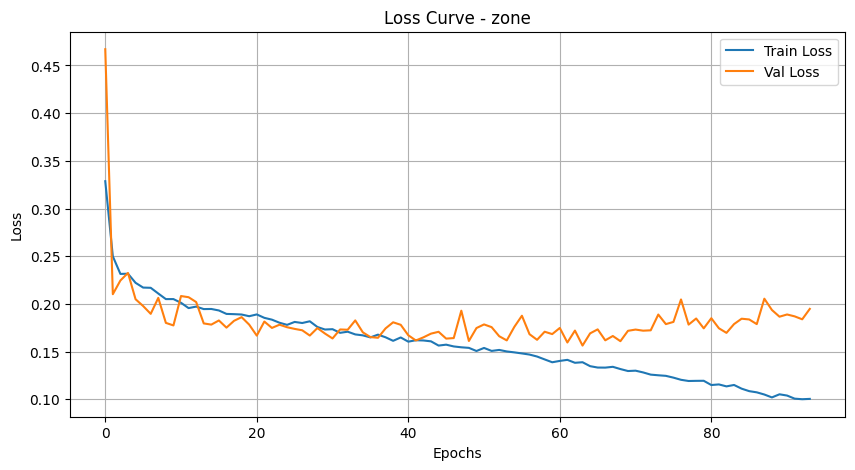

In [45]:
zone_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(zone_classifier_model.parameters(), lr=0.001)
train_model_with_loaders(zone_classifier_model, loaders, part_name='zone', criterion=criterion, optimizer=optimizer, device=device, num_epochs=100, patience=30)

📊 Classification Report - zone
              precision    recall  f1-score   support

       Upper       0.94      0.92      0.93      3031
       Lower       0.93      0.94      0.93      3114

    accuracy                           0.93      6145
   macro avg       0.93      0.93      0.93      6145
weighted avg       0.93      0.93      0.93      6145



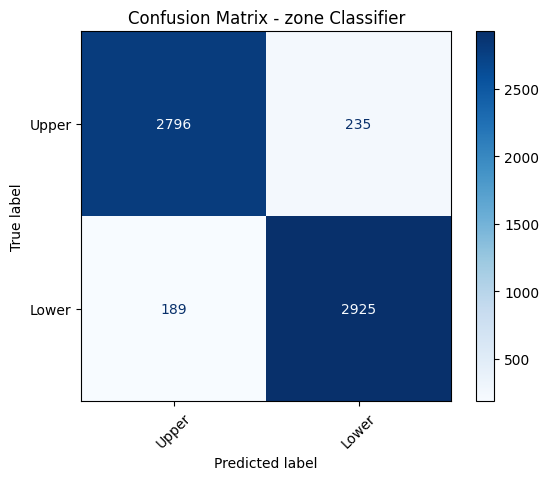

In [46]:
evaluate_model(zone_classifier_model, loaders, part_name='zone', class_names=["Upper", "Lower"], device=device)

[upper] Epoch 1, Train Loss: 0.4772, Val Loss: 0.4182
[upper] Epoch 2, Train Loss: 0.4491, Val Loss: 0.4139
[upper] Epoch 3, Train Loss: 0.4450, Val Loss: 0.4773
[upper] Epoch 4, Train Loss: 0.4332, Val Loss: 0.4588
[upper] Epoch 5, Train Loss: 0.4243, Val Loss: 0.4001
[upper] Epoch 6, Train Loss: 0.4228, Val Loss: 0.3887
[upper] Epoch 7, Train Loss: 0.4226, Val Loss: 0.4148
[upper] Epoch 8, Train Loss: 0.4148, Val Loss: 0.3913
[upper] Epoch 9, Train Loss: 0.4079, Val Loss: 0.3860
[upper] Epoch 10, Train Loss: 0.4020, Val Loss: 0.3798
[upper] Epoch 11, Train Loss: 0.3998, Val Loss: 0.4265
[upper] Epoch 12, Train Loss: 0.3956, Val Loss: 0.3820
[upper] Epoch 13, Train Loss: 0.3928, Val Loss: 0.4865
[upper] Epoch 14, Train Loss: 0.3867, Val Loss: 0.4142
[upper] Epoch 15, Train Loss: 0.3821, Val Loss: 0.3634
[upper] Epoch 16, Train Loss: 0.3800, Val Loss: 0.3590
[upper] Epoch 17, Train Loss: 0.3809, Val Loss: 0.4051
[upper] Epoch 18, Train Loss: 0.3782, Val Loss: 0.3655
[upper] Epoch 19, T

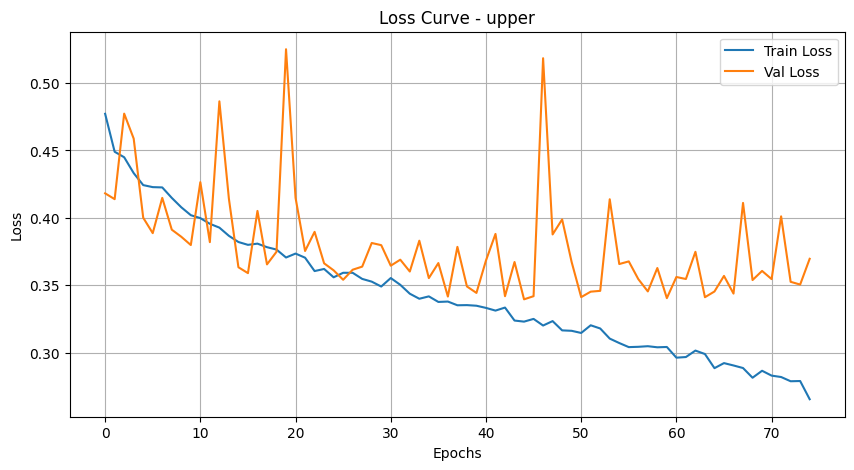

In [47]:
upper_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(upper_classifier_model.parameters(), lr=0.0001)
train_model_with_loaders(upper_classifier_model, loaders, part_name='upper', criterion=criterion, optimizer=optimizer, device=device, num_epochs=100, patience=30)

📊 Classification Report - upper
              precision    recall  f1-score   support

   Upper Arm       0.89      0.81      0.85      1400
     Forearm       0.81      0.88      0.84      1268

    accuracy                           0.85      2668
   macro avg       0.85      0.85      0.85      2668
weighted avg       0.85      0.85      0.85      2668



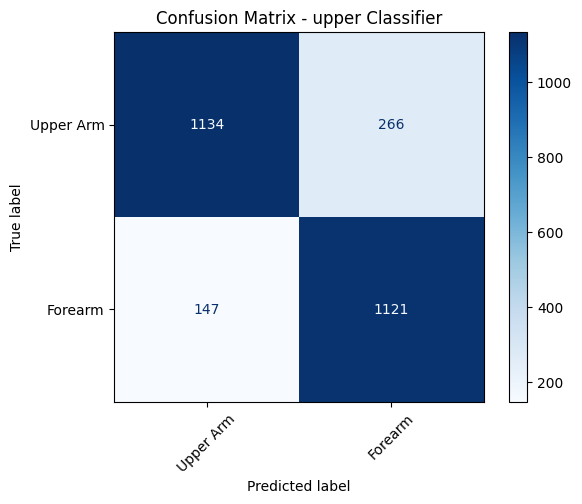

In [48]:
evaluate_model(upper_classifier_model, loaders, part_name='upper', class_names=["Upper Arm", "Forearm"], device=device)

[lower] Epoch 1, Train Loss: 0.6299, Val Loss: 0.6623
[lower] Epoch 2, Train Loss: 0.6039, Val Loss: 0.5975
[lower] Epoch 3, Train Loss: 0.5880, Val Loss: 0.6222
[lower] Epoch 4, Train Loss: 0.5786, Val Loss: 0.5705
[lower] Epoch 5, Train Loss: 0.5706, Val Loss: 0.6495
[lower] Epoch 6, Train Loss: 0.5626, Val Loss: 0.6525
[lower] Epoch 7, Train Loss: 0.5578, Val Loss: 0.5855
[lower] Epoch 8, Train Loss: 0.5464, Val Loss: 0.5412
[lower] Epoch 9, Train Loss: 0.5471, Val Loss: 0.6525
[lower] Epoch 10, Train Loss: 0.5410, Val Loss: 0.5764
[lower] Epoch 11, Train Loss: 0.5389, Val Loss: 0.5867
[lower] Epoch 12, Train Loss: 0.5291, Val Loss: 0.5930
[lower] Epoch 13, Train Loss: 0.5325, Val Loss: 0.5487
[lower] Epoch 14, Train Loss: 0.5286, Val Loss: 0.5317
[lower] Epoch 15, Train Loss: 0.5215, Val Loss: 0.5995
[lower] Epoch 16, Train Loss: 0.5177, Val Loss: 0.7613
[lower] Epoch 17, Train Loss: 0.5145, Val Loss: 0.5339
[lower] Epoch 18, Train Loss: 0.5083, Val Loss: 0.5344
[lower] Epoch 19, T

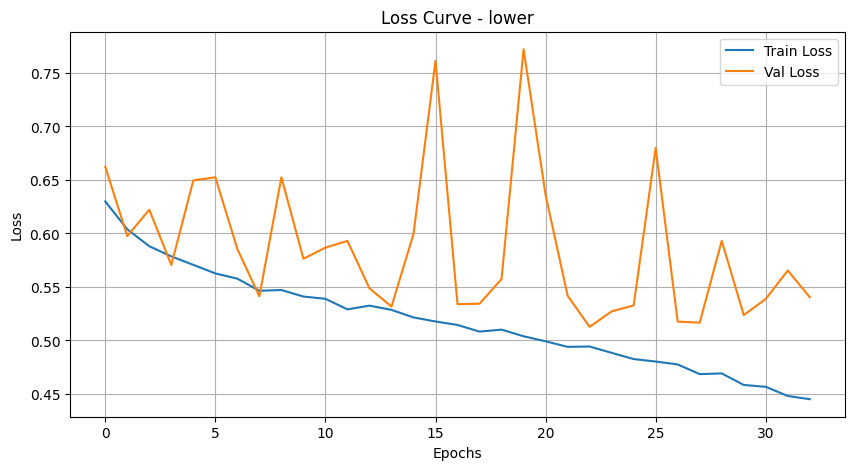

In [51]:
lower_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=9, kernel_sizes=[5, 10, 40])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lower_classifier_model.parameters(), lr=0.0001)
train_model_with_loaders(lower_classifier_model, loaders, part_name='lower', criterion=criterion, optimizer=optimizer, device=device, num_epochs=100, patience=10)

📊 Classification Report - lower
              precision    recall  f1-score   support

       Ankle       0.77      0.73      0.75      1400
        Knee       0.73      0.77      0.75      1320

    accuracy                           0.75      2720
   macro avg       0.75      0.75      0.75      2720
weighted avg       0.75      0.75      0.75      2720



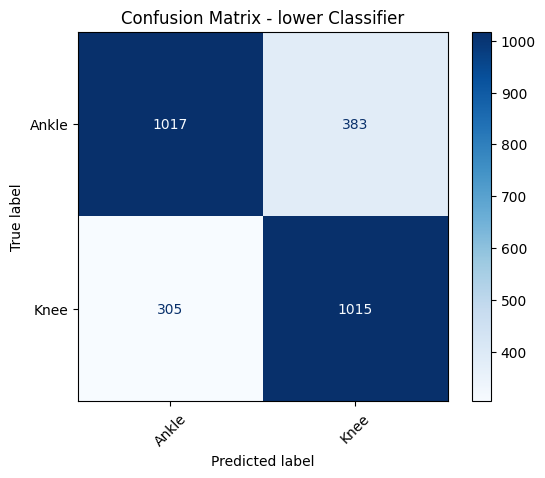

In [52]:
evaluate_model(lower_classifier_model, loaders, part_name='lower', class_names=["Ankle", "Knee"], device=device)

[forearm] Epoch 1, Train Loss: 0.7074, Val Loss: 0.6955
[forearm] Epoch 2, Train Loss: 0.6942, Val Loss: 0.7003
[forearm] Epoch 3, Train Loss: 0.6877, Val Loss: 0.6798
[forearm] Epoch 4, Train Loss: 0.6872, Val Loss: 0.6765
[forearm] Epoch 5, Train Loss: 0.6830, Val Loss: 0.6941
[forearm] Epoch 6, Train Loss: 0.6816, Val Loss: 0.7523
[forearm] Epoch 7, Train Loss: 0.6842, Val Loss: 0.6743
[forearm] Epoch 8, Train Loss: 0.6740, Val Loss: 0.6906
[forearm] Epoch 9, Train Loss: 0.6652, Val Loss: 0.6714
[forearm] Epoch 10, Train Loss: 0.6652, Val Loss: 0.6675
[forearm] Epoch 11, Train Loss: 0.6619, Val Loss: 0.6809
[forearm] Epoch 12, Train Loss: 0.6635, Val Loss: 0.6721
[forearm] Epoch 13, Train Loss: 0.6593, Val Loss: 0.7181
[forearm] Epoch 14, Train Loss: 0.6595, Val Loss: 0.7015
[forearm] Epoch 15, Train Loss: 0.6569, Val Loss: 0.6762
[forearm] Epoch 16, Train Loss: 0.6482, Val Loss: 0.6581
[forearm] Epoch 17, Train Loss: 0.6522, Val Loss: 0.6698
[forearm] Epoch 18, Train Loss: 0.6448, 

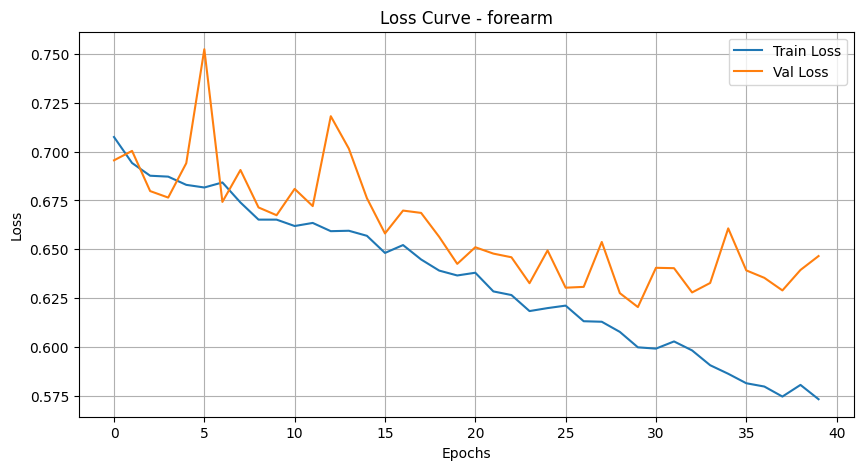

In [33]:
forearm_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=7)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(forearm_classifier_model.parameters(), lr=0.0002)
train_model_with_loaders(forearm_classifier_model, loaders, part_name='forearm', criterion=criterion, optimizer=optimizer, device=device)

📊 Classification Report - forearm
              precision    recall  f1-score   support

        Left       0.62      0.62      0.62       612
       Right       0.64      0.64      0.64       656

    accuracy                           0.63      1268
   macro avg       0.63      0.63      0.63      1268
weighted avg       0.63      0.63      0.63      1268



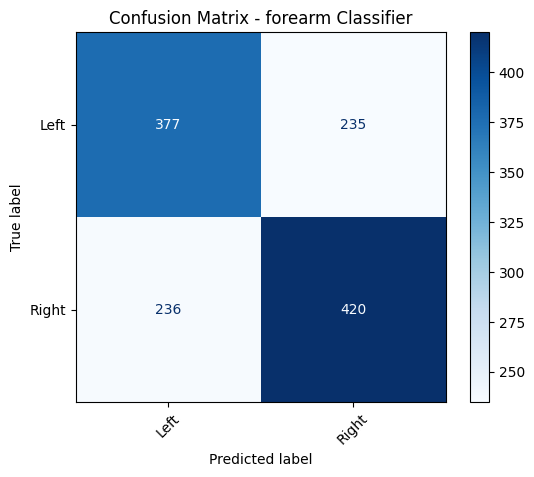

In [34]:
evaluate_model(forearm_classifier_model, loaders, part_name='forearm', class_names=["Left", "Right"], device=device)

[upperarm] Epoch 1, Train Loss: 0.6901, Val Loss: 0.6816
[upperarm] Epoch 2, Train Loss: 0.6724, Val Loss: 0.6651
[upperarm] Epoch 3, Train Loss: 0.6601, Val Loss: 0.6687
[upperarm] Epoch 4, Train Loss: 0.6502, Val Loss: 0.6431
[upperarm] Epoch 5, Train Loss: 0.6452, Val Loss: 0.6189
[upperarm] Epoch 6, Train Loss: 0.6446, Val Loss: 0.6309
[upperarm] Epoch 7, Train Loss: 0.6364, Val Loss: 0.6324
[upperarm] Epoch 8, Train Loss: 0.6367, Val Loss: 0.6046
[upperarm] Epoch 9, Train Loss: 0.6344, Val Loss: 0.6196
[upperarm] Epoch 10, Train Loss: 0.6317, Val Loss: 0.6373
[upperarm] Epoch 11, Train Loss: 0.6303, Val Loss: 0.6032
[upperarm] Epoch 12, Train Loss: 0.6208, Val Loss: 0.6102
[upperarm] Epoch 13, Train Loss: 0.6200, Val Loss: 0.6196
[upperarm] Epoch 14, Train Loss: 0.6215, Val Loss: 0.6319
[upperarm] Epoch 15, Train Loss: 0.6204, Val Loss: 0.6008
[upperarm] Epoch 16, Train Loss: 0.6225, Val Loss: 0.6058
[upperarm] Epoch 17, Train Loss: 0.6138, Val Loss: 0.6181
[upperarm] Epoch 18, Tr

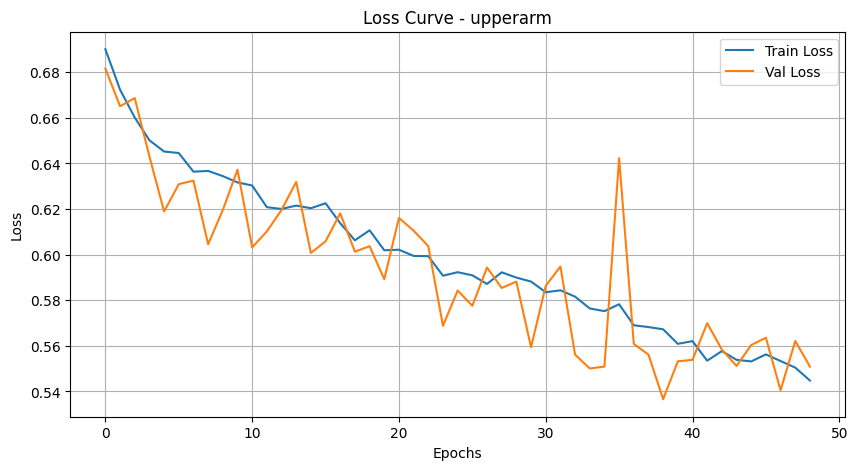

In [35]:
upperarm_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(upperarm_classifier_model.parameters(), lr=0.001)
train_model_with_loaders(upperarm_classifier_model, loaders, part_name='upperarm', criterion=criterion, optimizer=optimizer, device=device)

📊 Classification Report - upperarm
              precision    recall  f1-score   support

        Left       0.68      0.74      0.71       875
       Right       0.72      0.66      0.68       888

    accuracy                           0.70      1763
   macro avg       0.70      0.70      0.70      1763
weighted avg       0.70      0.70      0.69      1763



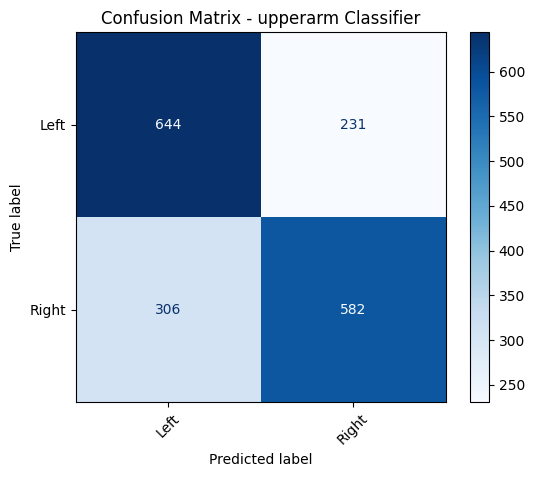

In [36]:
evaluate_model(upperarm_classifier_model, loaders, part_name='upperarm', class_names=["Left", "Right"], device=device)

[knee] Epoch 1, Train Loss: 0.7057, Val Loss: 0.6961
[knee] Epoch 2, Train Loss: 0.7047, Val Loss: 0.6903
[knee] Epoch 3, Train Loss: 0.7001, Val Loss: 0.6876
[knee] Epoch 4, Train Loss: 0.6953, Val Loss: 0.7064
[knee] Epoch 5, Train Loss: 0.6905, Val Loss: 0.6878
[knee] Epoch 6, Train Loss: 0.6904, Val Loss: 0.6858
[knee] Epoch 7, Train Loss: 0.6890, Val Loss: 0.6884
[knee] Epoch 8, Train Loss: 0.6845, Val Loss: 0.6847
[knee] Epoch 9, Train Loss: 0.6811, Val Loss: 0.6846
[knee] Epoch 10, Train Loss: 0.6778, Val Loss: 0.6813
[knee] Epoch 11, Train Loss: 0.6787, Val Loss: 0.6839
[knee] Epoch 12, Train Loss: 0.6769, Val Loss: 0.6814
[knee] Epoch 13, Train Loss: 0.6759, Val Loss: 0.6868
[knee] Epoch 14, Train Loss: 0.6743, Val Loss: 0.6847
[knee] Epoch 15, Train Loss: 0.6721, Val Loss: 0.6811
[knee] Epoch 16, Train Loss: 0.6670, Val Loss: 0.6791
[knee] Epoch 17, Train Loss: 0.6654, Val Loss: 0.6821
[knee] Epoch 18, Train Loss: 0.6617, Val Loss: 0.6884
[knee] Epoch 19, Train Loss: 0.6618, 

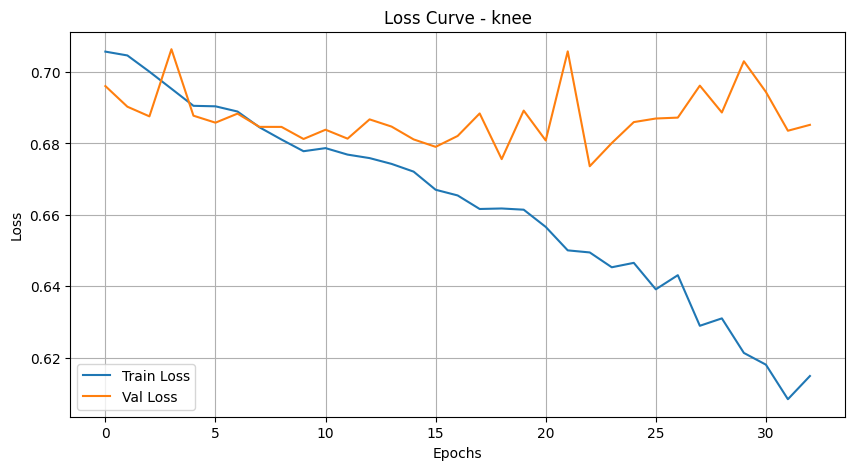

In [37]:
knee_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=9, kernel_sizes=[2, 10, 40])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(knee_classifier_model.parameters(), lr=0.0001)
train_model_with_loaders(knee_classifier_model, loaders, part_name='knee', criterion=criterion, optimizer=optimizer, device=device)

📊 Classification Report - knee
              precision    recall  f1-score   support

        Left       0.60      0.48      0.54       663
       Right       0.57      0.68      0.62       657

    accuracy                           0.58      1320
   macro avg       0.58      0.58      0.58      1320
weighted avg       0.58      0.58      0.58      1320



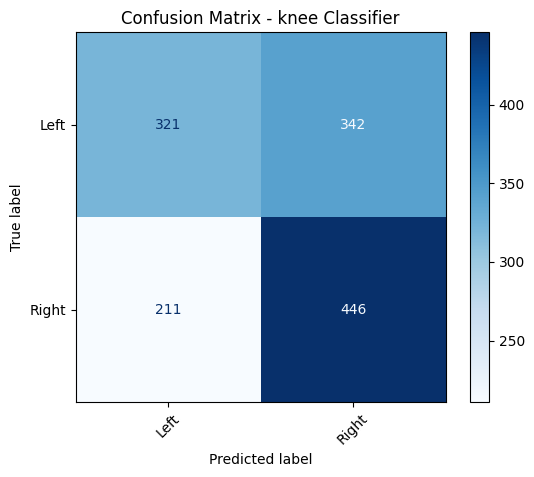

In [38]:
evaluate_model(knee_classifier_model, loaders, part_name='knee', class_names=["Left", "Right"], device=device)

[ankle] Epoch 1, Train Loss: 0.7007, Val Loss: 0.6976
[ankle] Epoch 2, Train Loss: 0.6954, Val Loss: 0.6851
[ankle] Epoch 3, Train Loss: 0.6850, Val Loss: 0.6818
[ankle] Epoch 4, Train Loss: 0.6830, Val Loss: 0.6784
[ankle] Epoch 5, Train Loss: 0.6791, Val Loss: 0.6972
[ankle] Epoch 6, Train Loss: 0.6794, Val Loss: 0.6781
[ankle] Epoch 7, Train Loss: 0.6754, Val Loss: 0.6838
[ankle] Epoch 8, Train Loss: 0.6733, Val Loss: 0.6833
[ankle] Epoch 9, Train Loss: 0.6725, Val Loss: 0.6762
[ankle] Epoch 10, Train Loss: 0.6670, Val Loss: 0.6811
[ankle] Epoch 11, Train Loss: 0.6686, Val Loss: 0.6716
[ankle] Epoch 12, Train Loss: 0.6640, Val Loss: 0.6831
[ankle] Epoch 13, Train Loss: 0.6637, Val Loss: 0.6742
[ankle] Epoch 14, Train Loss: 0.6605, Val Loss: 0.6821
[ankle] Epoch 15, Train Loss: 0.6602, Val Loss: 0.7191
[ankle] Epoch 16, Train Loss: 0.6561, Val Loss: 0.6610
[ankle] Epoch 17, Train Loss: 0.6524, Val Loss: 0.6932
[ankle] Epoch 18, Train Loss: 0.6516, Val Loss: 0.6738
[ankle] Epoch 19, T

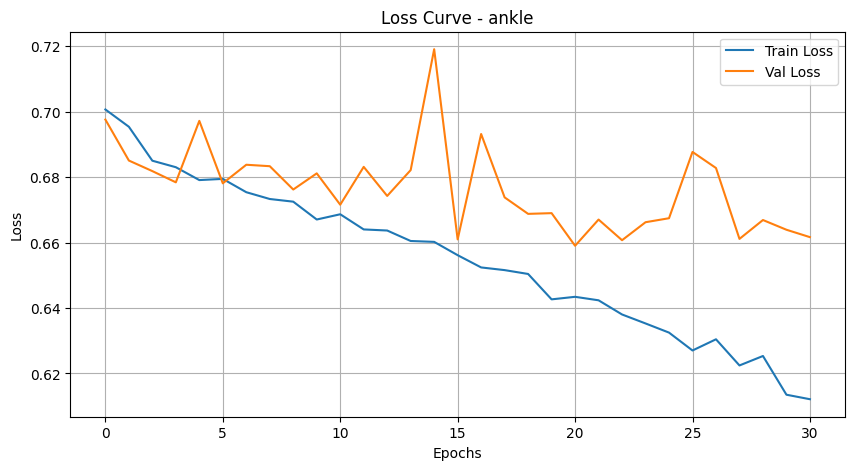

In [39]:
ankle_classifier_model = InceptionTimeClassifier(input_channels=1, num_classes=2, nb_blocks=9, kernel_sizes=[2, 10, 40])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ankle_classifier_model.parameters(), lr=0.0001)
train_model_with_loaders(ankle_classifier_model, loaders, part_name='ankle', criterion=criterion, optimizer=optimizer, device=device)

📊 Classification Report - ankle
              precision    recall  f1-score   support

        Left       0.64      0.46      0.54       906
       Right       0.57      0.73      0.64       890

    accuracy                           0.60      1796
   macro avg       0.60      0.60      0.59      1796
weighted avg       0.60      0.60      0.59      1796



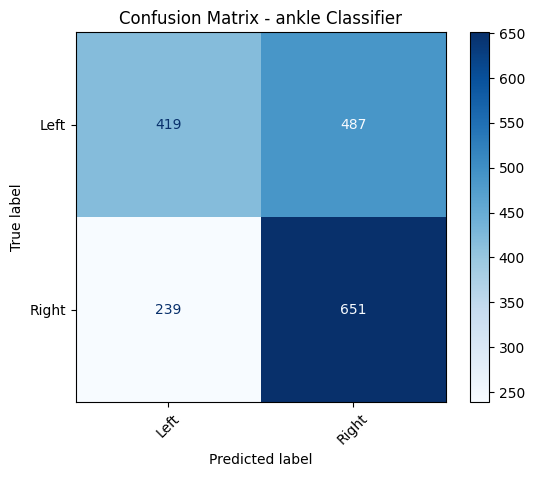

In [40]:
evaluate_model(ankle_classifier_model, loaders, part_name='ankle', class_names=["Left", "Right"], device=device)

In [41]:
torch.save(upper_classifier_model, "upper_classifier_model.pt")
torch.save(lower_classifier_model, "lower_classifier_model.pt")
torch.save(forearm_classifier_model, "forearm_classifier_model.pt")
torch.save(upperarm_classifier_model, "upperarm_classifier_model.pt")
torch.save(ankle_classifier_model, "ankle_classifier_model.pt")
torch.save(knee_classifier_model, "knee_classifier_model.pt")

In [42]:
data.shape

(30725, 502)